# Install Triton and verify installation

In [8]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [9]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [10]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# 2D Convolution
$$y[o_h, o_w]
=
\sum_{k_h=0}^{K_H-1} \sum_{k_w=0}^{K_W-1}
x[o_h \cdot s + k_h - \left\lfloor \frac{K_H}{2} \right\rfloor,\;
  o_w \cdot s + k_w - \left\lfloor \frac{K_W}{2} \right\rfloor]
\cdot
w[k_h, k_w]$$

### Kernel and Wrapper

In [11]:
@triton.jit
def conv_2d_kernel(
    # Pointers to input
    x_ptr, weight_ptr, output_ptr,
    # Input dimensions
    H, W, KH, KW, OH, OW,
    # Strides
    stride,
    stride_xh, stride_xw,
    stride_oh, stride_ow,
    # Meta-parameters
    BLOCK_SIZE_H: tl.constexpr,
    BLOCK_SIZE_W: tl.constexpr,
):
    # Tile output and launch one program for each tile in output. Map program id to tile coordinates
    # Tile order in column-major index ordering
    pid = tl.program_id(axis=0) # Index of tile in column-major index ordering
    num_pid_h = tl.cdiv(OH, BLOCK_SIZE_H) # Number of tiles (programs) along H dimension in output
    pid_h = pid % num_pid_h # Row index of tile (program) in output (along H)
    pid_w = pid // num_pid_h # Column index of tile (program) in output (along W)

    # Compute tile offsets
    offsets_oh = pid_h * BLOCK_SIZE_H + tl.arange(0, BLOCK_SIZE_H)
    offsets_ow = pid_w * BLOCK_SIZE_W + tl.arange(0, BLOCK_SIZE_W)

    # Centring shift
    half_kh = KH // 2
    half_kw = KW // 2

    # Initialize accumulator
    accumulator = tl.zeros((BLOCK_SIZE_H, BLOCK_SIZE_W), dtype=tl.float32)

    for kh in range(KH):
        for kw in range(KW):
            curr_window_h = (offsets_oh * stride) + kh - half_kh
            curr_window_w = (offsets_ow * stride) + kw - half_kw

            # Verify boundary for out-of-bounds
            mask = (
                (curr_window_h[:, None] >= 0) &
                (curr_window_h[:, None] < H) &
                (curr_window_w[None, :] >= 0) &
                (curr_window_w[None, :] < W) &
                (offsets_oh[: None] < OH) &
                (offsets_ow[None, :] < OW)
            )

            # Load input tile and single weight
            x_ptrs = x_ptr + curr_window_h[:, None] * stride_xh + curr_window_w[None, :] * stride_xw
            x = tl.load(x_ptrs, mask=mask, other=0.0)
            w = tl.load(weight_ptr + kh * KW + kw) # 2D weight flattened to 1D

            # Multiply and accumulate
            accumulator += x * w

    # Store accumulated output
    output_mask = (offsets_oh[:, None] < OH) & (offsets_ow[None, :] < OW)
    output_ptrs = output_ptr + offsets_oh[:, None] * stride_oh + offsets_ow[None, :] * stride_ow
    tl.store(output_ptrs, value=accumulator, mask=output_mask)


def conv_2d(x, weight, stride=1, BLOCK_SIZE_H=32, BLOCK_SIZE_W=32):
    # Input dimens
    H, W = x.shape
    KH, KW = weight.shape

    # Calculate output dimensions
    OH = (H + stride - 1) // stride
    OW = (W + stride - 1) // stride
    
    # Allocate output
    output = torch.empty((OH, OW), device=x.device, dtype=x.dtype)

    # Define launch grid: 1D grid that represents total number of tiles in output
    grid = lambda meta: (
        triton.cdiv(OH, meta["BLOCK_SIZE_H"]) * triton.cdiv(OW, meta["BLOCK_SIZE_W"]),
    )

    # Call kernel
    conv_2d_kernel[grid](
        # Pointers to inputs
        x, weight, output,
        # Input dimensions
        H, W, KH, KW, OH, OW,
        # Strides
        stride,
        x.stride(0), x.stride(1),
        output.stride(0), output.stride(1),
        # Meta-parameters
        BLOCK_SIZE_H=BLOCK_SIZE_H,
        BLOCK_SIZE_W=BLOCK_SIZE_W,
    )

    return output

### Test and Benchmark Helpers

In [12]:
def test_conv_2d_kernel(size: tuple, weight_size: int, stride: int, atol=1e-6, rtol=1e-5, device=DEVICE):
    torch.manual_seed(42)
    assert isinstance(size, tuple) and len(size) == 2

    H, W = size
    K = weight_size
    half_k = K // 2

    x = torch.randn(H, W, device=device)
    weight = torch.randn(K, K, device=device)

    # Triton output
    output_triton = conv_2d(x, weight, stride=stride)

    # PyTorch output
    pad_h = weight_size // 2
    pad_w = weight_size // 2
    x_4d = x.unsqueeze(0).unsqueeze(0) # [1, 1, H, W]
    weight_4d = weight.view(1, 1, K, K) # [1, 1, K, K]
    
    # Pad PyTorch input symmetrically (left, right, top, bottom)
    x_padded = torch.nn.functional.pad(x_4d, (pad_w, pad_w, pad_h, pad_h), mode="constant", value=0)

    output_ref = torch.nn.functional.conv2d(x_padded, weight_4d, stride=stride).squeeze()
    
    torch.testing.assert_close(output_triton, output_ref, atol=atol, rtol=rtol)
    print("Passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["K"],
        x_vals=[i for i in range(1, 50, 2)], # Odd filter widths
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"],
        styles=[("blue", "-"), ("red", "-")],
        ylabel="GB/s",
        plot_name="conv-2d-performance",
        args={"H": 2048, "W": 2048, "stride": 2},
    )
)
def benchmark(H, W, K, stride, provider):
    torch.manual_seed(42)

    x = torch.randn((H, W), device=DEVICE, dtype=torch.float32)
    weight = torch.randn((K, K), device=DEVICE, dtype=torch.float32)
    
    pad = K // 2
    quantiles = [0.15, 0.5, 0.85]

    if provider == "torch":
        x_4d = x.unsqueeze(0).unsqueeze(0) # [1, 1, H, W]
        weight_4d = weight.view(1, 1, K, K) # [1, 1, 1, K]
        x_padded = torch.nn.functional.pad(x_4d, (pad, pad, pad, pad), mode="constant", value=0)
        min_ms, ms, max_ms = triton.testing.do_bench(
            lambda: torch.nn.functional.conv2d(
                x_padded,
                weight_4d,
                stride=stride
            ).squeeze(),
            quantiles=quantiles,
        )
    elif provider == "triton":
        min_ms, ms, max_ms = triton.testing.do_bench(
            lambda: conv_2d(x, weight, stride=stride),
            quantiles=quantiles,
        )

    # Output size for same padding
    OH = (H + 2 * pad - K) // stride + 1
    OW = (W + 2 * pad - K) // stride + 1

    # Approximate bytes moved: read x + read weight + write output
    bytes_moved = (
        x.numel() * x.element_size()
        + weight.numel() * weight.element_size()
        + OH * OW * x.element_size()
    )
    
    gbps = lambda ms: bytes_moved * 1e-9 / (ms * 1e-3)
    return gbps(min_ms), gbps(ms), gbps(max_ms)

## Test

In [13]:
test_conv_2d_kernel((1024, 1024), 5, stride=1)
test_conv_2d_kernel((2048, 4096), 11, stride=2)

Passed
Passed


## Benchmark

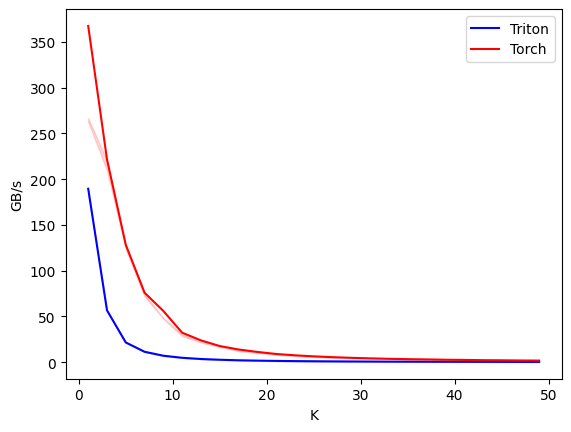

conv-2d-performance:
       K      Triton       Torch
0    1.0  189.574811  367.560371
1    3.0   56.668609  221.705393
2    5.0   21.551794  128.306340
3    7.0   11.350159   75.899557
4    9.0    7.030284   55.959061
5   11.0    4.770875   32.202000
6   13.0    3.450709   23.790256
7   15.0    2.625331   17.621347
8   17.0    2.047741   13.855569
9   19.0    1.652776   11.188044
10  21.0    1.356550    8.938251
11  23.0    1.133666    7.483464
12  25.0    0.967552    6.345242
13  27.0    0.829230    5.452948
14  29.0    0.718569    4.732634
15  31.0    0.630728    4.151257
16  33.0    0.554276    3.668074
17  35.0    0.493437    3.262863
18  37.0    0.441865    3.002106
19  39.0    0.394276    2.633743
20  41.0    0.360539    2.449026
21  43.0    0.328626    2.168883
22  45.0    0.300265    2.037134
23  47.0    0.274501    1.833381
24  49.0    0.252898    1.718498


In [14]:
benchmark.run(print_data=True, show_plots=True)

# Scratch